In [88]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


In [89]:
# Upload the cleaned and sampled dataset
df = pd.read_excel('../data/properties_sampled.xlsx')

## Transform data - feature engineering

In [90]:
# Zamień kolumnę 'construction_year' na 'building_age' (wiek mieszkania)
current_year = pd.Timestamp.now().year
df['building_age'] = current_year - df['construction_year']
df = df.drop(columns=['construction_year'])

### Transform latitute and logitutate into districts

In [91]:
# Load districts GeoJSON
districts = gpd.read_file("../data/warszawa-dzielnice.geojson")
districts = districts.to_crs(epsg=4326) 

In [92]:
# Exclude 'Warszawa' district from the analysis as it is not a valid district
districts = districts[districts['name'] != 'Warszawa']

In [93]:
# Create GeoDataFrame from df points
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
df_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# Spatial join: find district for each point
result = gpd.sjoin(df_gdf, districts, how='left', predicate='within')

In [94]:
# Remove duplicate index by grouping and taking the first match
district_series = result.groupby(result.index)['name'].first()
df['district'] = district_series

In [95]:
# Remove rows where district could not be assigned (i.e., district is NaN)
df = df[df['district'].notna()]

### Odległość od metra

In [96]:
stations = [
    ("Kabaty", 52.131222, 21.065824),
    ("Natolin", 52.140203, 21.057709),
    ("Imielin", 52.149919, 21.045560),
    ("Stokłosy", 52.156010, 21.034454),
    ("Ursynów", 52.161899, 21.027310),
    ("Służew", 52.173098, 21.026369),
    ("Wilanowska", 52.181673, 21.022982),
    ("Wierzbno", 52.189900, 21.016825),
    ("Racławicka", 52.199369, 21.012154),
    ("Pole Mokotowskie", 52.208606, 21.007864),
    ("Politechnika", 52.217619, 21.014673),
    ("Centrum", 52.229812, 21.011643),
    ("Świętokrzyska", 52.235270, 21.008575),
    ("Ratusz Arsenał", 52.244610, 21.001224),
    ("Dworzec Gdański", 52.258080, 20.994779),
    ("Plac Wilsona", 52.268823, 20.985170),
    ("Marymont", 52.271893, 20.970699),
    ("Słodowiec", 52.276942, 20.960029),
    ("Stare Bielany", 52.281706, 20.949219),
    ("Wawrzyszew", 52.286273, 20.939508),
    ("Młociny", 52.290646, 20.930182),
    ("Bemowo", 52.239227, 20.915040),
    ("Ulrychów", 52.240358, 20.930003),
    ("Księcia Janusza", 52.239166, 20.942638),
    ("Młynów", 52.237543, 20.960662),
    ("Płocka", 52.232800, 20.965934),
    ("Rondo Daszyńskiego", 52.230420, 20.983315),
    ("Rondo ONZ", 52.233150, 20.998176),
    ("Nowy Świat-Uniwersytet", 52.237030, 21.017660),
    ("Centrum Nauki Kopernik", 52.239538, 21.031238),
    ("Stadion Narodowy", 52.246919, 21.043167),
    ("Dworzec Wileński", 52.254154, 21.035130),
    ("Szwedzka", 52.263355, 21.045245),
    ("Targówek Mieszkaniowy", 52.269588, 21.051441),
    ("Trocka", 52.275312, 21.055723),
    ("Zacisze", 52.284251, 21.062036),
    ("Kondratowicza", 52.292042, 21.050196),
    ("Bródno", 52.293518, 21.029058)
]

In [97]:
def haversine(lat1, lon1, lat2, lon2):
    # Calculate the great-circle distance between two points on the Earth
    R = 6371  # Earth radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

station_coords = np.array([(lat, lon) for _, lat, lon in stations])

def min_station_distance(row):
    dists = haversine(row['latitude'], row['longitude'], station_coords[:,0], station_coords[:,1])
    return dists.min()

df['dist_to_metro_km'] = df.apply(min_station_distance, axis=1)

### Odległość od centrum

In [98]:
# Find coordinates of "Centrum" station
centrum_station = next((lat, lon) for name, lat, lon in stations if name == "Centrum")

# Calculate distance from each row to "Centrum" station
df['dist_to_centrum_km'] = df.apply(
    lambda row: haversine(row['surface'], row['rooms'], centrum_station[0], centrum_station[1])
    if 'latitude' not in df.columns else haversine(row['latitude'], row['longitude'], centrum_station[0], centrum_station[1]),
    axis=1
)

### Zachodnia i wschodnia strona wisły

In [99]:
left_side_districts = {
    'Śródmieście', 'Mokotów', 'Wola', 'Ochota', 'Ursynów', 'Włochy', 'Bemowo',
    'Wilanów', 'Ursus', 'Bielany', 'Żoliborz'
}

right_side_districts = {
    'Praga Północ', 'Praga Południe', 'Targówek', 'Białołęka',
    'Rembertów', 'Wesoła', 'Wawer'
}

In [100]:
def map_river_side(district):
    if district in left_side_districts:
        return 'zachodnia'
    elif district in right_side_districts:
        return 'wschodnia'
    else:
        raise ValueError(f"District '{district}' not found in either side mapping.")

df['river_side'] = df['district'].apply(map_river_side)


In [101]:
# Drop unnecessary columns
df = df.drop(columns=['geometry', 'latitude', 'longitude'])

### get rid of outliers

In [102]:
# Remove rows with building_age < -5 or building_age > 300
df = df[(df['building_age'] >= -5) & (df['building_age'] <= 300)]

In [103]:
# Remove rows where 'floor' is outside the valid range (-1 to 30)
df = df[(df['floor'] >= -1) & (df['floor'] <= 30)]

In [104]:
# Remove outliers for all numerical columns except 'dist_to_metro_km' and 'dist_to_centrum_km'
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['dist_to_metro_km', 'dist_to_centrum_km']]
for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    mask = df[col].isna() | ((df[col] >= mean - 3 * std) & (df[col] <= mean + 3 * std))
    df = df[mask]

## Analysis of the data
- price has near normal distribution

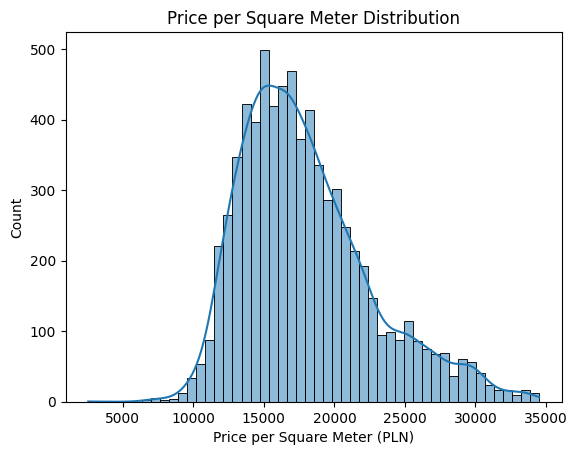

In [105]:
# Visualize price per square meter distribution (only non-null)
sns.histplot(df['price_per_square_meter'].dropna(), bins=50, kde=True)
plt.title("Price per Square Meter Distribution")
plt.xlabel("Price per Square Meter (PLN)")
plt.ylabel("Count")
plt.show()

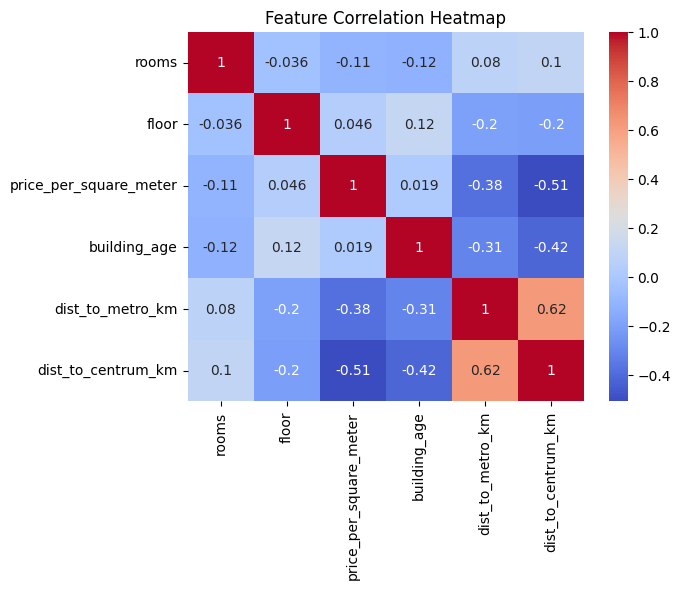

In [107]:
df.isna().sum()

rooms                        0
floor                        0
material                     0
market                       0
price_per_square_meter    1151
building_age                 0
district                     0
dist_to_metro_km             0
dist_to_centrum_km           0
river_side                   0
dtype: int64

In [108]:
# Count apartments in each district, split by whether price per square meter is NaN or not
district_price_counts = df.groupby(['district', df['price_per_square_meter'].isna()]).size().unstack(fill_value=0)
district_price_counts.columns = ['price_not_nan', 'price_nan']
district_price_counts = district_price_counts[['price_not_nan', 'price_nan']]  # for column order

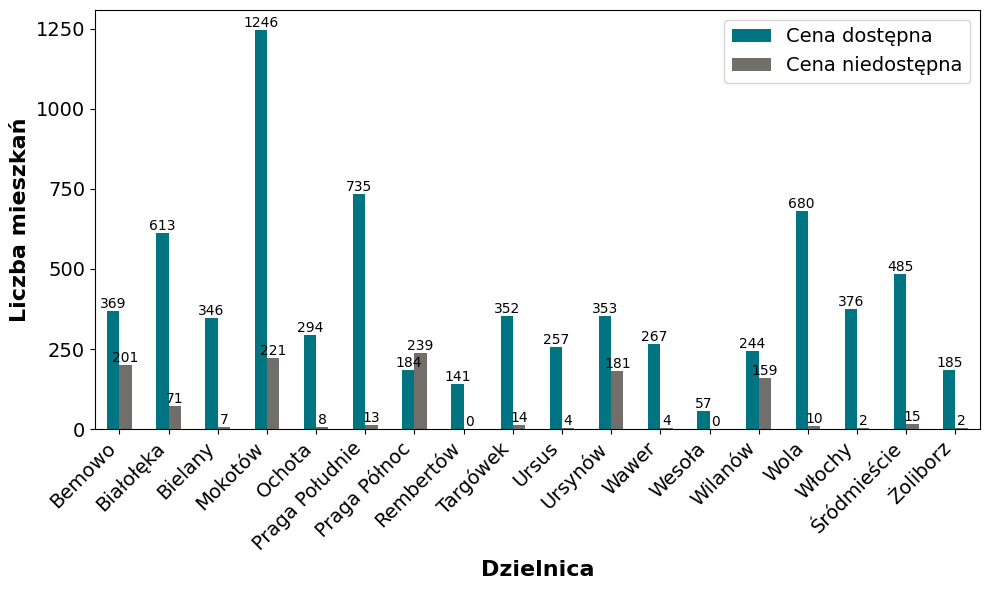

In [109]:
# Bar chart: count of apartments in each district, split by price known/unknown
# Customizable colors and legend labels
color_has_price = '#007481'      # Color for apartments with known price
color_missing_price = '#726F6B'  # Color for apartments with missing price
legend_has_price = 'Cena dostępna'       # Legend label for known price
legend_missing_price = 'Cena niedostępna'   # Legend label for missing price

# Create the plot with custom colors
ax = district_price_counts.plot(kind='bar', stacked=False, figsize=(10, 6),
                               color=[color_has_price, color_missing_price])

# Set labels and formatting
plt.xlabel('Dzielnica', fontsize=16, fontweight='bold')
plt.ylabel('Liczba mieszkań', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))  # Limit to ~6 y-axis ticks

# Update legend with custom labels
ax.legend([legend_has_price, legend_missing_price], loc='upper right', fontsize=14)

# Add value annotations on bars
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
# bielany, żoliborz, rembertów, wesoła, ochota, ursus, śródmieście

In [110]:
# Average price per m² in each district (excluding NaN by default)
avg_price_per_square_meter = df.groupby('district')['price_per_square_meter'].mean()

# Optional alignment to district map index used in the next cell
avg_price_per_square_meter = avg_price_per_square_meter.reindex(districts['name'])


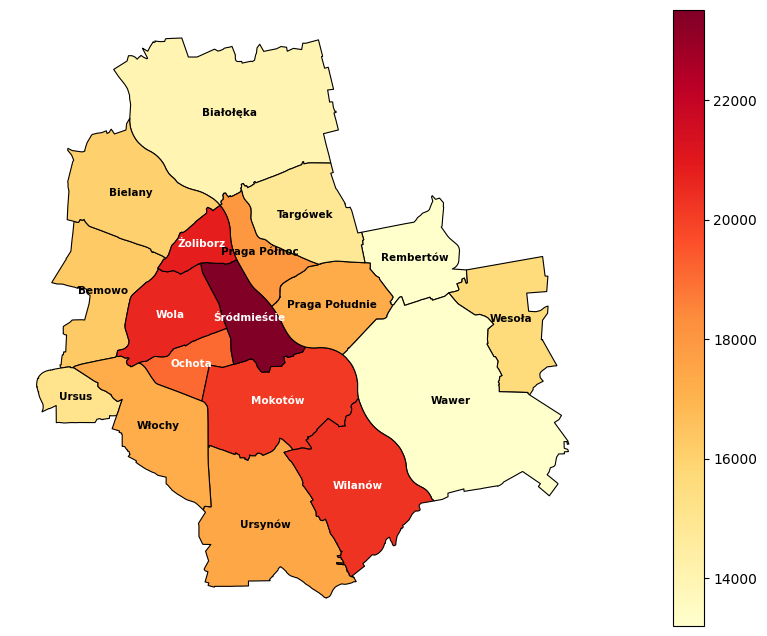

In [111]:
# **Calculate average price per surface for each district (already done as price_per_square_meter)**
# **Merge with districts GeoDataFrame for mapping**

# **Ensure the district names match between price_per_square_meter and districts['name']**
districts_map = districts.set_index('name').copy()
districts_map['avg_price_per_square_meter'] = avg_price_per_square_meter

# **Plot the map**
fig, ax = plt.subplots(figsize=(20, 8))
districts_map.plot(column='avg_price_per_square_meter', cmap='YlOrRd', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
# ax.set_title('Średnia cena za m² w dzielnicach Warszawy', fontsize=16)
ax.axis('off')

# **Add district names with contrasting colors**
# Get min and max values for normalization
min_val = districts_map['avg_price_per_square_meter'].min()
max_val = districts_map['avg_price_per_square_meter'].max()

for idx, row in districts_map.iterrows():
    if row['geometry'].centroid.is_empty or pd.isna(row['avg_price_per_square_meter']):
        continue
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    
    # Normalize the value to determine text color (0 = light color, 1 = dark color)
    normalized_val = (row['avg_price_per_square_meter'] - min_val) / (max_val - min_val)
    
    # Use white text for dark backgrounds (high values) and black text for light backgrounds (low values)
    text_color = 'white' if normalized_val > 0.5 else 'black'
    
    plt.text(x, y, idx, fontsize=7.5, ha='center', va='center', fontweight='bold', color=text_color)

plt.show()

### One-hot encoding

In [112]:
# # Encode categorical variables
# cat_features = ['material', 'heating', 'district', 'sewage', 'river_side']
# df = pd.get_dummies(df, columns=cat_features, drop_first=True)

In [113]:
# # Step 5: Save Model
# import joblib
# joblib.dump(model, '../data/price_model.pkl')

# # Save encoded feature columns for future encoding
# joblib.dump(X.columns.tolist(), '../data/feature_columns.pkl')

In [114]:
# # List all possible options for non-numerical columns before one-hot encoding

# # Select columns with object dtype (categorical/text)
# categorical_cols = df_gdf.select_dtypes(include=['object']).columns

# # For each categorical column, print unique values
# for col in categorical_cols:
#     unique_vals = df_gdf[col].unique()
#     print(f"{col}:")
#     print(unique_vals)
#     print("-" * 40)

ANALIZA BRAKUJĄCYCH DANYCH CENOWYCH
Łączna liczba wierszy: 8,335
Wiersze z ceną: 7,184 (86.2%)
Wiersze bez ceny: 1,151 (13.8%)


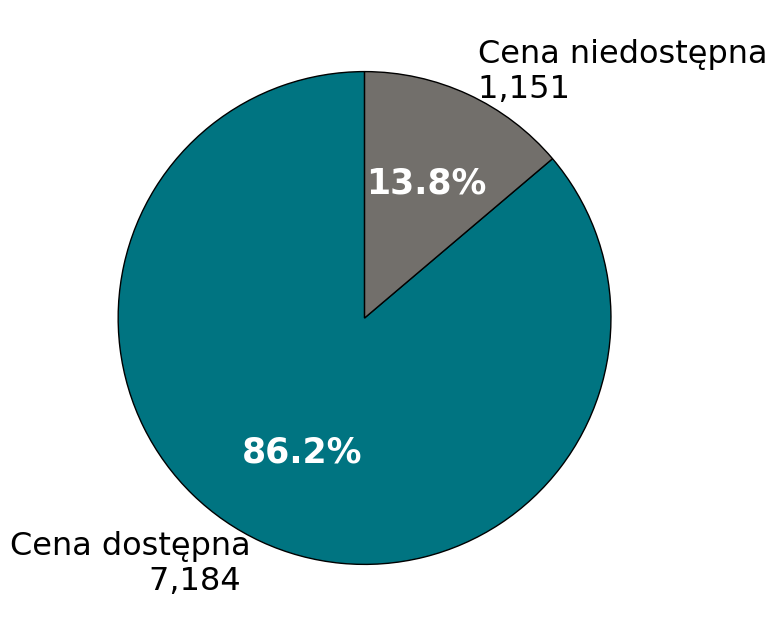

In [115]:
# Wizualizacja brakujących danych cenowych z konfigurowalnymi kolorami
def visualize_missing_prices(df, color_has_price='#007481', color_missing_price='#726F6B'):
    """
    Wizualizuje rozkład brakujących i istniejących cen
    
    Parametry:
    df: DataFrame
    color_has_price: kolor hex dla wierszy z ceną (domyślnie: niebieski)
    color_missing_price: kolor hex dla wierszy bez ceny (domyślnie: czerwony)
    """
    
    # Oblicz liczby i procenty
    price_counts = df['price_per_square_meter'].isna().value_counts().sort_index()
    total_rows = len(df)
    
    has_price_count = price_counts[False] if False in price_counts else 0
    missing_price_count = price_counts[True] if True in price_counts else 0
    
    has_price_pct = (has_price_count / total_rows) * 100
    missing_price_pct = (missing_price_count / total_rows) * 100
    
    # Wyświetl statystyki podsumowujące
    print("="*60)
    print("ANALIZA BRAKUJĄCYCH DANYCH CENOWYCH")
    print("="*60)
    print(f"Łączna liczba wierszy: {total_rows:,}")
    print(f"Wiersze z ceną: {has_price_count:,} ({has_price_pct:.1f}%)")
    print(f"Wiersze bez ceny: {missing_price_count:,} ({missing_price_pct:.1f}%)")
    print("="*60)
    
    # Wykres kołowy - procenty
    labels = [f'Cena dostępna\n{has_price_count:,} ', 
              f'Cena niedostępna\n{missing_price_count:,} ']
    sizes = [has_price_pct, missing_price_pct]
    colors = [color_has_price, color_missing_price]
    
    plt.figure(figsize=(8, 8))
    wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors, 
                                      autopct='%1.1f%%', startangle=90,
                                      textprops={'fontsize': 23},
                                      wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    
    # Ustaw tekst procentowy na pogrubiony i biały
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(25)
    
    # plt.title('Rozkład Procentowy Dostępności Ceny', fontsize=30, fontweight='bold')
    plt.show()
    
    return {
        'total_rows': total_rows,
        'has_price_count': has_price_count,
        'missing_price_count': missing_price_count,
        'has_price_percentage': has_price_pct,
        'missing_price_percentage': missing_price_pct
    }

# Przykład użycia z domyślnymi kolorami (niebieski dla ceny, czerwony dla braku ceny)
stats = visualize_missing_prices(df)

Analiza brakujących cen według typu rynku:
ANALIZA BRAKUJĄCYCH CENY WG TYPU RYNKU
Łączna liczba mieszkań: 8,335

RYNEK PIERWOTNY:
  Łącznie mieszkań: 2,117
  Cena dostępna: 1,078 (50.9%)
  Cena niedostępna: 1,039 (49.1%)

RYNEK WTÓRNY:
  Łącznie mieszkań: 6,218
  Cena dostępna: 6,106 (98.2%)
  Cena niedostępna: 112 (1.8%)


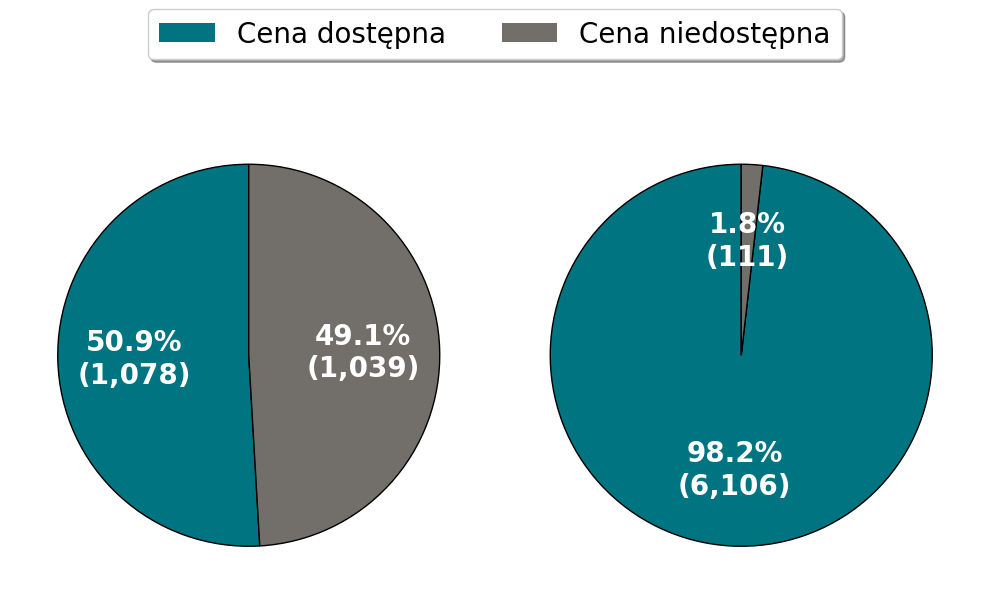

In [117]:
# Wizualizacja brakujących cen w podziale na rynek pierwotny/wtórny
def visualize_missing_prices_by_market(df, color_primary='#2E86C1', color_secondary='#E74C3C', 
                                      color_missing='#726F6B', color_has_price='#007481'):
    """
    Wizualizuje rozkład brakujących i istniejących cen w podziale na rynek pierwotny i wtórny
    
    Parametry:
    df: DataFrame
    color_primary: kolor hex dla rynku pierwotnego (domyślnie: niebieski)
    color_secondary: kolor hex dla rynku wtórnego (domyślnie: czerwony)  
    color_missing: kolor hex dla brakujących cen (domyślnie: pomarańczowy)
    color_has_price: kolor hex dla istniejących cen (domyślnie: zielony)
    """
    
    # Utwórz tabelę krzyżową: rynek vs dostępność ceny
    market_price_crosstab = pd.crosstab(df['market'], df['price_per_square_meter'].isna(), margins=True)
    market_price_crosstab.columns = ['Cena dostępna', 'Cena niedostępna', 'Łącznie']
    market_price_crosstab.index = ['Pierwotny', 'Wtórny', 'Łącznie']
    
    # Oblicz procenty
    total_rows = len(df)
    primary_total = len(df[df['market'] == 'pierwotny'])
    secondary_total = len(df[df['market'] == 'wtórny'])

    primary_has_price = market_price_crosstab.loc['Pierwotny', 'Cena dostępna']
    primary_missing_price = market_price_crosstab.loc['Pierwotny', 'Cena niedostępna']
    secondary_has_price = market_price_crosstab.loc['Wtórny', 'Cena dostępna']
    secondary_missing_price = market_price_crosstab.loc['Wtórny', 'Cena niedostępna']

    # Wyświetl statystyki podsumowujące
    print("="*70)
    print("ANALIZA BRAKUJĄCYCH CENY WG TYPU RYNKU")
    print("="*70)
    print(f"Łączna liczba mieszkań: {total_rows:,}")
    print("\nRYNEK PIERWOTNY:")
    print(f"  Łącznie mieszkań: {primary_total:,}")
    print(f"  Cena dostępna: {primary_has_price:,} ({primary_has_price/primary_total*100:.1f}%)")
    print(f"  Cena niedostępna: {primary_missing_price:,} ({primary_missing_price/primary_total*100:.1f}%)")
    print("\nRYNEK WTÓRNY:")
    print(f"  Łącznie mieszkań: {secondary_total:,}")
    print(f"  Cena dostępna: {secondary_has_price:,} ({secondary_has_price/secondary_total*100:.1f}%)")
    print(f"  Cena niedostępna: {secondary_missing_price:,} ({secondary_missing_price/secondary_total*100:.1f}%)")
    print("="*70)
    
    # Utwórz wizualizację - tylko wykresy kołowe
    fig, axes = plt.subplots(1, 2, figsize=(10, 7))
    
    # 1. Wykres kołowy - rynek pierwotny
    primary_sizes = [primary_has_price, primary_missing_price]
    primary_labels = [f'Cena dostępna\n{primary_has_price:,}', f'Cena niedostępna\n{primary_missing_price:,}']
    primary_colors = [color_has_price, color_missing]
    
    # Funkcja do formatowania etykiet z liczbami i procentami
    def autopct_format_primary(pct):
        absolute = int(pct/100.*primary_total)
        return f'{pct:.1f}%\n({absolute:,})'
    
    if primary_missing_price > 0:  # Tylko jeśli są brakujące dane
        wedges1, texts1, autotexts1 = axes[0].pie(primary_sizes,  
                                                    colors=primary_colors, autopct=autopct_format_primary,
                                                    startangle=90, textprops={'fontsize': 18},
                                                    wedgeprops={'edgecolor': 'black'})
        for autotext in autotexts1:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(20)
    else:
        axes[0].pie([1], colors=[color_has_price], labels=[f'Wszystkie z ceną\n{primary_has_price:,}'])
    
    # axes[0].set_title(f'Rynek Pierwotny\n({primary_total:,} mieszkań)', fontsize=16, fontweight='bold')
    
    # 2. Wykres kołowy - rynek wtórny  
    secondary_sizes = [secondary_has_price, secondary_missing_price]
    secondary_labels = [f'Cena dostępna\n{secondary_has_price:,}', f'Cena niedostępna\n{secondary_missing_price:,}']
    secondary_colors = [color_has_price, color_missing]
    
    # Funkcja do formatowania etykiet z liczbami i procentami
    def autopct_format_secondary(pct):
        absolute = int(pct/100.*secondary_total)
        return f'{pct:.1f}%\n({absolute:,})'
    
    if secondary_missing_price > 0:  # Tylko jeśli są brakujące dane
        wedges2, texts2, autotexts2 = axes[1].pie(secondary_sizes, 
                                                    colors=secondary_colors, autopct=autopct_format_secondary,
                                                    startangle=90, textprops={'fontsize': 18},
                                                    wedgeprops={'edgecolor': 'black'})
        for autotext in autotexts2:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(20)
    else:
        axes[1].pie([1], colors=[color_has_price], labels=[f'Wszystkie z ceną\n{secondary_has_price:,}'])
    
    # axes[1].set_title(f'Rynek Wtórny\n({secondary_total:,} mieszkań)', fontsize=16, fontweight='bold')
    
    # Dodaj wspólną legendę
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_has_price, label='Cena dostępna'),
        Patch(facecolor=color_missing, label='Cena niedostępna')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
               ncol=2, fontsize=20, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Zrób miejsce na legendę
    plt.show()
    
    return market_price_crosstab

# Przykład użycia z domyślnymi kolorami
print("Analiza brakujących cen według typu rynku:")
crosstab_result = visualize_missing_prices_by_market(df)

# Saving dataframe

In [118]:
df.to_excel('../data/properties_modified.xlsx', index=False)